In [1]:
import numpy as np
import pickle
# Number of parameters
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, CenteredNorm
import matplotlib.ticker as ticker
from matplotlib.patches import Ellipse
from matplotlib.transforms import blended_transform_factory

import functions as func
from functions import adjust_angle
from mcmc import ln_prob

In [120]:
file_pick = open('mcmc_samples_2025/both_mcmc_24_02_2025_warner.obj', 'rb')
#file_pick = open('mcmc_samples_final/mcmc_full_2.obj', 'rb')
sampler = pickle.load(file_pick)

In [121]:
# best without warner
# [1.4002, 0.8269, 0.8264, 1.0977, 1.0962, 0.3953, 1.4161, -1.4048, 1.6851, 0.2091, 2998.6834, 2.0254]
# best with warner
# [1.4103, 0.8306, 0.8291, 1.0406, 1.0396, 0.3798, 1.4099, -1.3903, 1.6836, 0.2091, 2476.7444, 2.0162]

In [122]:
thin = 1
samples = sampler.get_chain(flat=True) * (sampler.params_max - sampler.params_min) + sampler.params_min
flat_ln = sampler.flatlnprobability[::thin][np.isfinite(sampler.flatlnprobability[::thin])]
samples = samples[np.argwhere(flat_ln != -np.inf), :][:, 0]
min_arg = flat_ln.argmax()
min_chi = flat_ln[min_arg]
print(f'len_samples_all: {len(samples)}', f'len_samples_notna: {len(samples)}')
print(f"min_arg: {min_arg}, min_chi: {min_chi}")
best_params = samples[min_arg]
print("""best_params: a1 = {:.2f},  b1 = {:.2f}, c1 = {:.2f},
             a2 = {:.2f}, b2 = {:.2f}, c2 = {:.2f},
             lon = {:.2f}, lat = {:.2f}, phase = {:.2f}""".format(*best_params))


print('best:      ', [round(float(param), 5) for param in best_params])

len_samples_all: 7913882 len_samples_notna: 7913882
min_arg: 7450477, min_chi: -42374.84370039749
best_params: a1 = 1.28,  b1 = 1.17, c1 = 0.50,
             a2 = 1.26, b2 = 0.84, c2 = 0.84,
             lon = 4.29, lat = -1.70, phase = 1.44
best:       [1.28191, 1.17208, 0.50424, 1.26138, 0.83876, 0.83702, 4.29429, -1.69971, 1.43816, 0.2091, 2373.36262, 2.22369]


In [127]:
# read the bootstraps
bt_results = np.array(func.read_bootstrap_from_file('data/bootstrap_warner_x3.txt'))
full_opt_results = np.array(func.read_bootstrap_from_file('data/fullopt_data_werner_3xerrs.txt'))
# select results (q=0.1) with lowest chi2
quant = 0.1
bt_results_best = bt_results[np.where(bt_results[:, 12] <= np.quantile(bt_results[:, 12], q=quant))]
full_opt_best = full_opt_results[np.where(full_opt_results[:, 12] <= np.quantile(full_opt_results[:, 12], q=quant))]
print(len(bt_results), len(full_opt_results))

350 60


In [128]:
print(list([float(val) for val in full_opt_best[0][:-1]]))

[1.3593, 0.8009, 0.7826, 1.1013, 1.0992, 0.4238, 1.677, -1.4511, 1.9717, 0.2091, 1862.3203, 2.1459]


/tmp/ipykernel_6269/2924345315.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.1, h_pad=-0.4, w_pad=0.0)


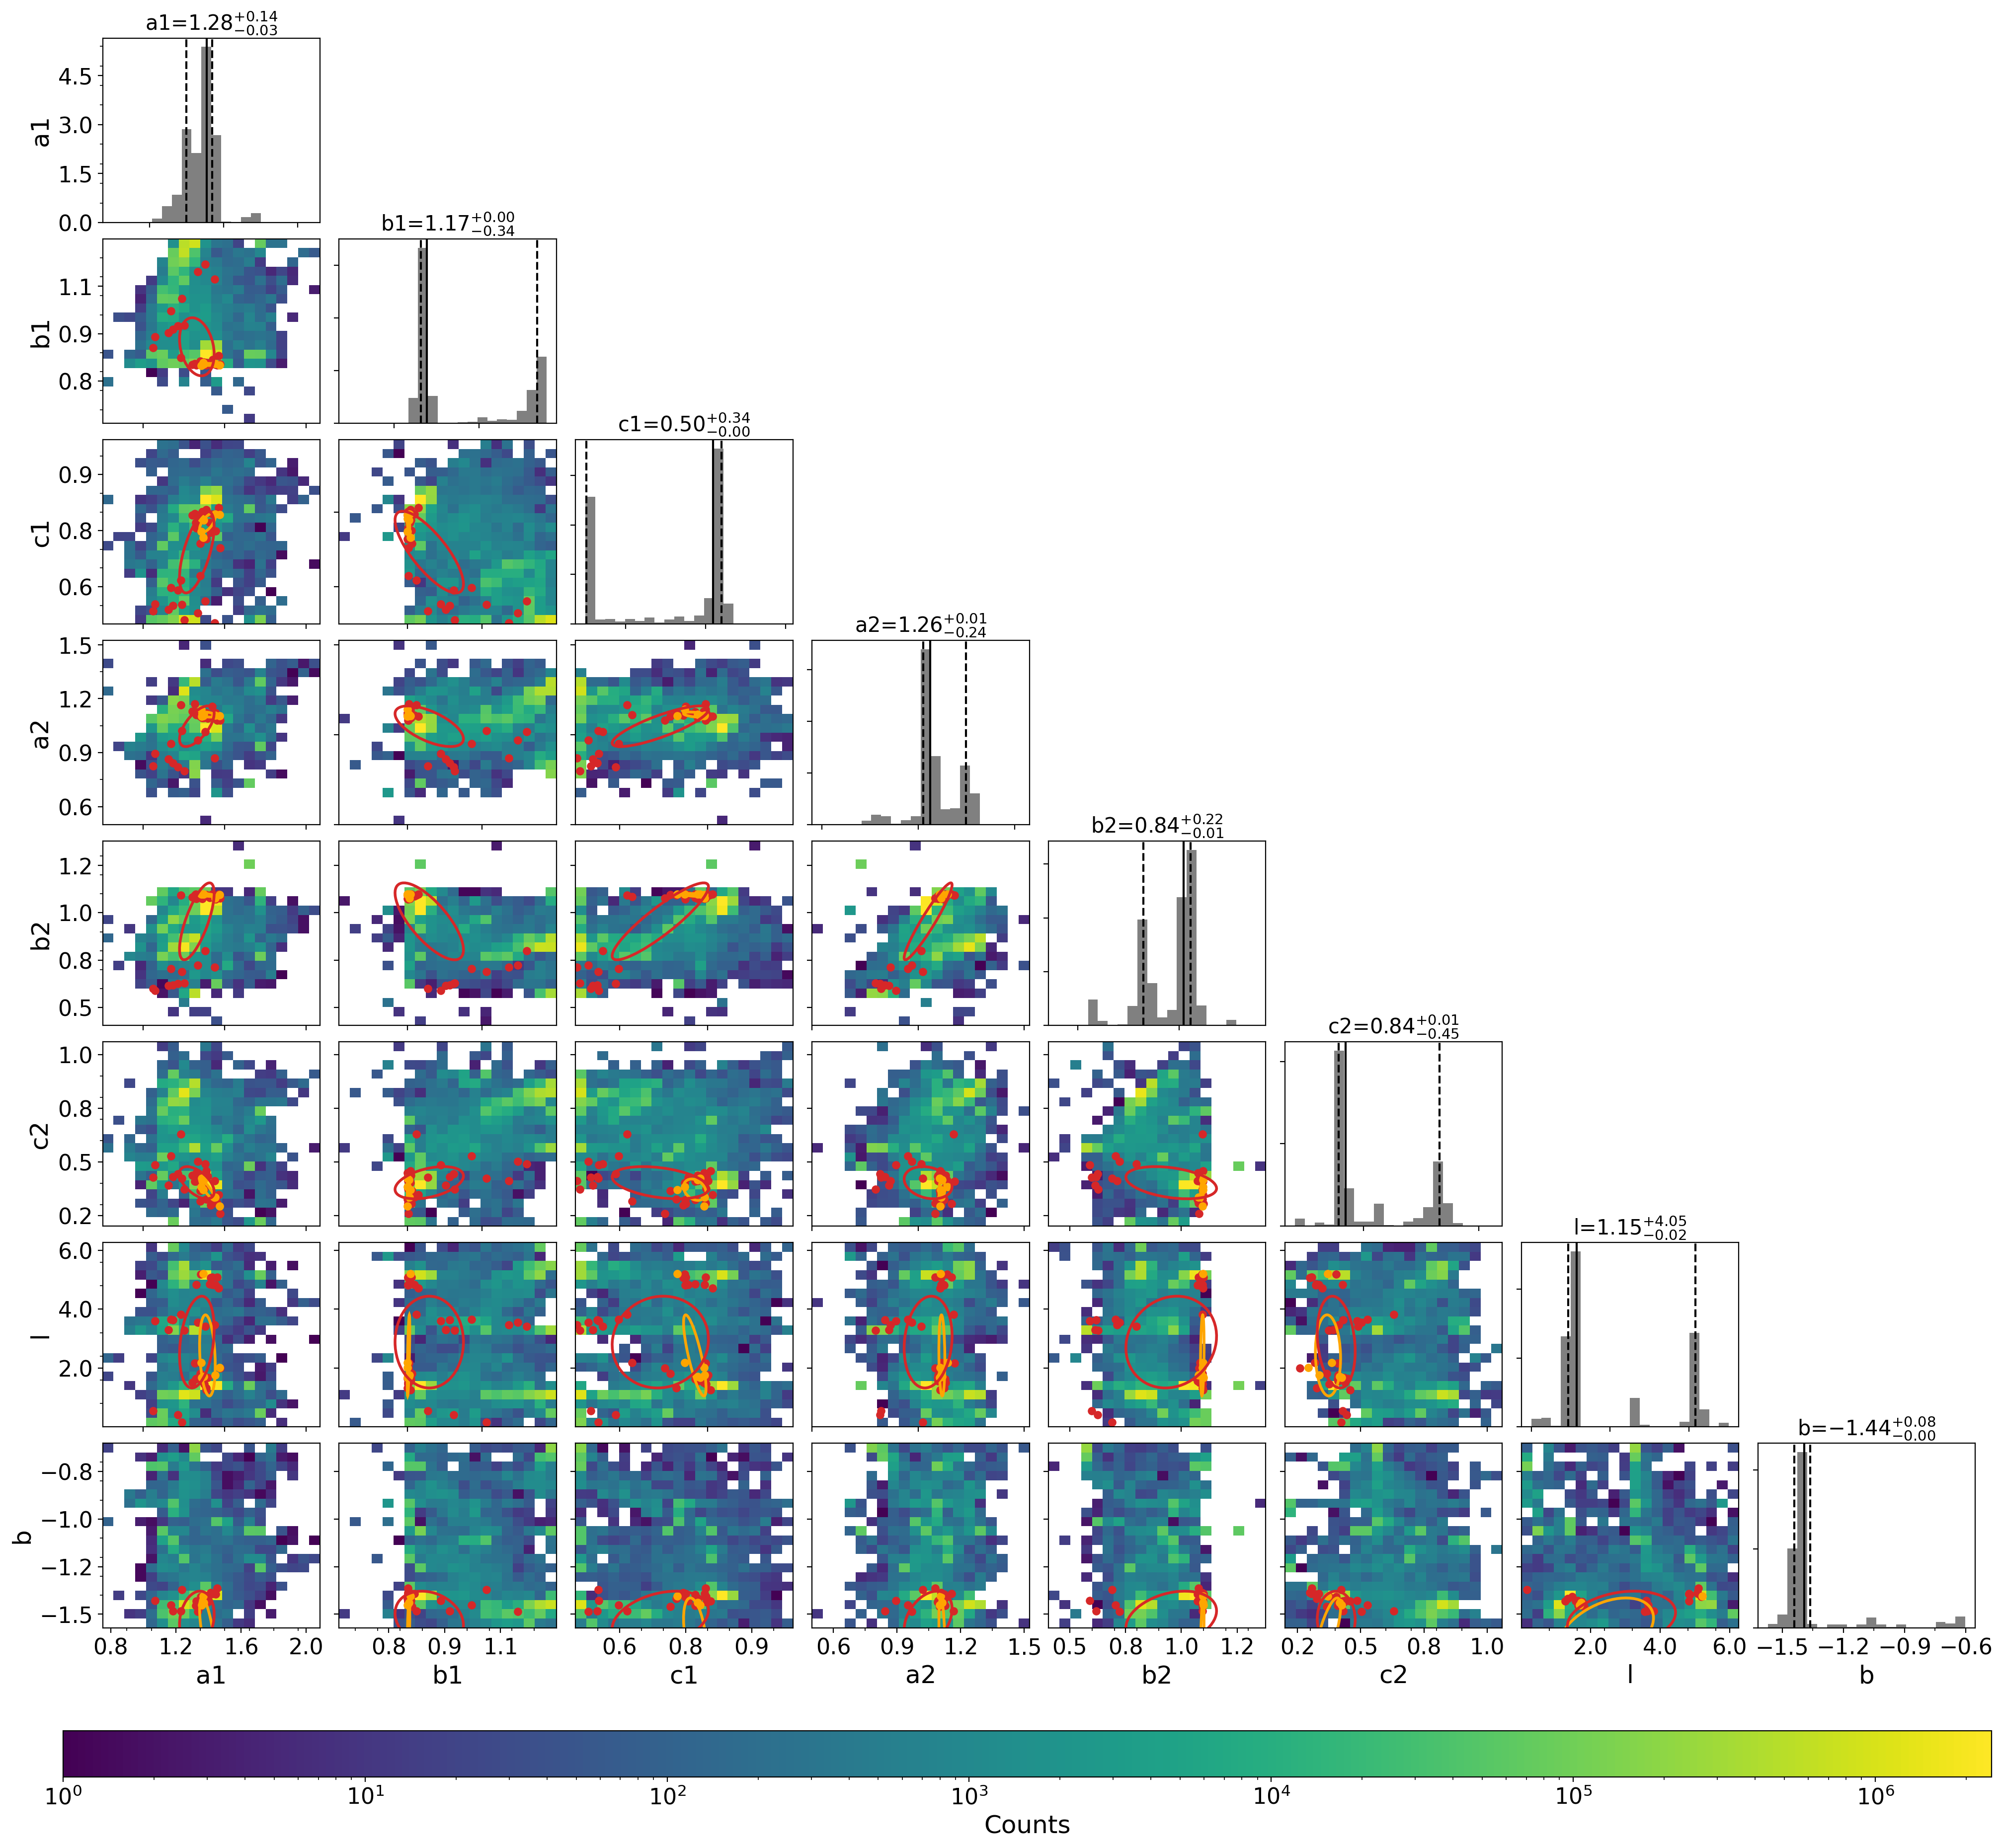

In [129]:
data = samples[:, :8]#[len(samples_flat) //2 :]
data[:, 6:8] = func.adjust_angle(data)


points = bt_results_best # bootstraps
full_points = full_opt_best # full data optimizers
# lc_points = np.array(lc_results)
# rad_points = np.array(radar_results)
num_params = data.shape[1]

labels=["a1", "b1", "c1", "a2", "b2", "c2", "l", "b", "phi0"]

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 15
# Create a figure with subplots
fig, axes = plt.subplots(num_params, num_params, figsize=(20, 20), dpi=200)
bins_heat = 20
bins_hist = 20
best_params_hist = samples[min_arg]

# Variable to store the mappable object for the colorbar
mappable = None
# Plot the histograms and scatter plots
for i in range(num_params):
    for j in range(num_params):
        if i < j:
            # Skip the upper triangle and diagonal
            axes[i, j].axis('off')
        elif i == j:
            # get the desired percentiles
            data_axis = data[:, i]
            p16 = np.percentile(data_axis, q=16)
            p84 = np.percentile(data_axis, q=84)
            median = np.median(data_axis)
            # data_axis = data_axis[(data_axis >= p16) & (data_axis <= p84)]
            # Diagonal: plot histograms
            axes[i, j].hist(data_axis, bins=bins_hist, color='gray', density=True)
            axes[i, j].axvline(median, color='black')
            axes[i, j].axvline(p16, color='black', linestyle='--')
            axes[i, j].axvline(p84, color='black', linestyle='--')
            # Add title with median and percentiles
            axes[i, j].title.set_text(r'%s=${%.2f}_{-%.2f}^{+%.2f}$' % (labels[i], round(best_params_hist[i],2),
                                                                  abs(round(best_params_hist[i]-p16, 2)), abs(round(p84 - best_params_hist[i], 2))))
        else:
            # Off-diagonal: plot scatter plots
            data_j = data[:, j]
            data_i = data[:, i]
            p16j = np.percentile(data_j, q=16)
            p84j = np.percentile(data_j, q=84)
            idx_j = np.argwhere((data_j >= p16j) & (data_j <= p84j))

            #h = axes[i, j].hist2d(data_j[idx_j][:, 0], data_i[idx_j][:, 0], bins=bins_heat, cmap='viridis', norm=LogNorm())
            h = axes[i, j].hist2d(data_j, data_i, bins=bins_heat, cmap='viridis', norm=LogNorm())

            # plot bootstraps
            idx1, idx2 = j, i
            axes[i, j].scatter(points[:, idx1], points[:, idx2], label='bootsraps', color='tab:red', s=25) # red is bootstrap
            axes[i, j].scatter(full_points[:, idx1], full_points[:, idx2], label='full opt', color='orange', s=25) # purple is fullopt
            # axes[i, j].scatter(rad_points[:, idx1], rad_points[:, idx2], label='radar points', color='tab:orange', s=25)
            # rad_mean, rad_width, rad_height, rad_angle = calc_ellips(np.array([rad_points[:, idx1], rad_points[:, idx2]]).T)
            # axes[i, j].add_patch(Ellipse(xy=rad_mean, width=rad_width, height=rad_height, angle=rad_angle, edgecolor='tab:orange', fc='None', lw=2, label='Uncertainty Ellipsoid'))
            full_mean, full_width, full_height, full_angle = func.calc_ellips(np.array([full_points[:, idx1], full_points[:, idx2]]).T)
            axes[i, j].add_patch(Ellipse(xy=full_mean, width=full_width, height=full_height, angle=full_angle, edgecolor='orange', fc='None', lw=2, label='Uncertainty Ellipsoid'))
            mean, width, height, angle = func.calc_ellips(np.array([points[:, idx1], points[:, idx2]]).T)
            axes[i, j].add_patch(Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='tab:red', fc='None', lw=2, label='Uncertainty Ellipsoid'))
            if mappable is None:
                mappable = h[3]  # Store the mappable object for the colorbar
            #axes[i, j].set_xlabel(labels[j])

        # Remove labels for cleaner look
        if i < num_params - 1:
            axes[i, j].set_xticklabels([])
        if j > 0:
            axes[i, j].set_yticklabels([])

        # Add axis labels
        if i == num_params - 1:
            axes[i, j].set_xlabel(labels[j])
            axes[i, j].xaxis.set_major_locator(ticker.MaxNLocator(4))
            axes[i, j].xaxis.set_minor_locator(ticker.MaxNLocator(10))
            axes[i, j].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))
        if j == 0:
            axes[i, j].set_ylabel(labels[i])
            axes[i, j].yaxis.set_major_locator(ticker.MaxNLocator(4))
            axes[i, j].yaxis.set_minor_locator(ticker.MaxNLocator(10))
            axes[i, j].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))


# Add a colorbar at the bottom for all subplots
if mappable:
    #cbar_ax = fig.add_axes([0.09, 0.06, 0.84, 0.02])
    cbar = fig.colorbar(mappable, ax=axes, orientation='horizontal', fraction=0.03, pad=-0.23, shrink=100.0, aspect=42)
    cbar.set_label('Counts')

#plt.legend()
# Adjust layout
plt.tight_layout(pad=0.1, h_pad=-0.4, w_pad=0.0)
#plt.savefig('article_images/correlation_mcmc_new.png', bbox_inches='tight', format='png')
#plt.savefig('article_images/correlation_mcmc.pdf', bbox_inches='tight', format='pdf')
plt.show()

## Build solution for the pole in polar coordinates

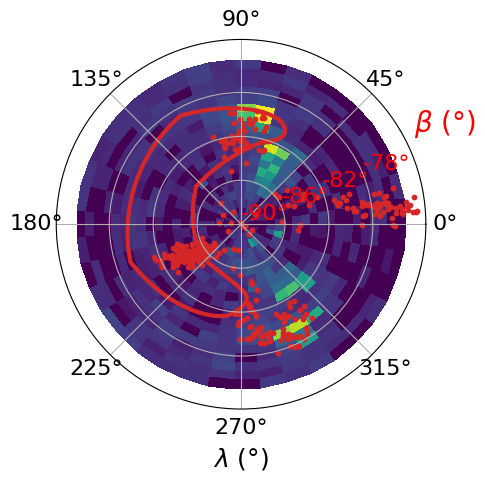

In [126]:
def adjust_angle(params):
    # adjust lambdas
    lambdas = params[:, 6]
    betas = params[:, 7]
    lambdas = np.where(betas < -np.pi/2, lambdas + np.pi, lambdas)
    lambdas = np.where(lambdas > 2*np.pi, lambdas - 2*np.pi, lambdas)
    # # # adjust_beta
    betas = np.where(betas < -np.pi / 2, -np.pi - betas, betas)
    #betas = np.where(betas > -1.05, -1, betas)
    return np.array([lambdas, betas]).T

data = samples[:, :9]
data[:, 6:8] = adjust_angle(data)
points = np.array(bt_results_best)
points[:, 6:8] = adjust_angle(points)
i = 7
j = 6
lat_data, lon_data = data[:, j], np.degrees(data[:, i])
# Define custom bin edges for theta and r
lon_edges = np.linspace(-90, -75, 20)
lat_edges = np.linspace(0, 2*np.pi, 40)

#lon_edges = np.linspace(-90, -0, 30)  # 20 bins for theta
#lat_edges = np.linspace(lat.data.min(), lat_data.max(), 40)  # 10 bins for r


# Create a 2D histogram with custom bin edges
hist, lat_edges, lon_edges = np.histogram2d(lat_data, lon_data, bins=[lat_edges, lon_edges])
#print(hist, lon_edges, lat_edges)

# Set up the polar plot
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

# Get the centers of the bins
lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
T, R = np.meshgrid(lat_centers, lon_centers)

from matplotlib.colors import PowerNorm
# Plot the 2D histogram in polar coordinates
ax.pcolormesh(T, R, hist.T,
              norm=PowerNorm(gamma=0.2),
              cmap='viridis')

# plot the results of optimizers
ax.scatter(points[:, j], np.degrees(points[:, i]), label='both points', color='tab:red', s=10)

mean, width, height, angle = func.calc_ellips(np.array([points[:, j], np.degrees(points[:, i])]).T)
ax.add_patch(Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='tab:red', fc='None', lw=3))
# vertices = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='tab:red', fc='None', lw=2).get_path().vertices
# ax.scatter(vertices[:, 0], np.degrees(vertices[:, 1]), label='both points', color='tab:red', s=25)

# Set axis labels with LaTeX formatting
ax.set_xlabel(r'$\lambda$ ($\degree$)', labelpad=50)  # Using \lambda for radius
#ax.set_ylabel(r'$\beta$ ($\degree$)', labelpad=30)  # Using \beta for angle


# set number of x and y ticks

ax.xaxis.set_label_coords(0.5, -0.1)  # x, y coordinates for x-axis label
ax.yaxis.set_label_coords(-0.1, 0.45)  # x, y coordinates for y-axis label
# Change the color of r ticks to white
ax.tick_params(axis='y', colors='white')

# Change the r tick labels to include degree symbols and set the angle

ax.set_yticks(np.arange(-90, -75, 4))
y_ticks = ax.get_yticks()
y_tick_labels = [f"{tick:.0f}°" for tick in y_ticks]
ax.set_yticklabels(y_tick_labels, color='red')
ax.annotate(r'$\beta$ ($\degree$)', xy=(1.05, 0.75), xycoords='axes fraction', ha='center', rotation=0, fontsize=20, color='red')

# # Change the x tick labels to include \lambda
# x_ticks = ax.get_xticks()
# x_tick_labels = [f"$\lambda$={np.degrees(tick):.1f}" for tick in x_ticks]
# ax.set_xticklabels(x_tick_labels)

plt.savefig('article_images/polar2.png', bbox_inches='tight', format='png', dpi=300)
plt.show()

In [24]:
print(points[:, 6].min(), points[:, 6].max())
print(points[:, 7].min(), points[:, 7].max())

0.14470734641020755 5.329592653589794
-1.4511 -1.3585926535897932


(array([2., 0., 0., 0., 0., 0., 0., 0., 1., 3.]),
 array([1.677     , 2.04225927, 2.40751853, 2.7727778 , 3.13803706,
        3.50329633, 3.86855559, 4.23381486, 4.59907412, 4.96433339,
        5.32959265]),
 <BarContainer object of 10 artists>)

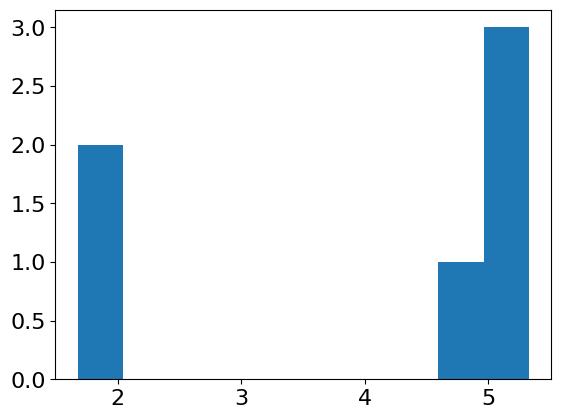

In [22]:
plt.hist(points[:, 6])

In [166]:
# read radar only and lightcurve only data
lc_results = np.array(func.read_bootstrap_from_file('data/lc_only_full_data.txt'))
radar_results = np.array(func.read_bootstrap_from_file('data/radar_only_full_data.txt'))
full_opt_results = np.array(func.read_bootstrap_from_file('data/fullopt_data_werner_3xerrs.txt'))
lt_correct = np.array(func.read_bootstrap_from_file('data/full_opt_lt_time_warner.txt'))
# select results (q=0.1) with lowest chi2
quant = 0.5
full_opt_best = full_opt_results[np.where(full_opt_results[:, 12] <= np.quantile(full_opt_results[:, 12], q=quant))]
lc_best = lc_results[np.where(lc_results[:, 12] <= np.quantile(lc_results[:, 12], q=quant))]
radar_best = radar_results[np.where(radar_results[:, 12] <= np.quantile(radar_results[:, 12], q=quant))]
lt_best = lt_correct[np.where(lt_correct[:, 12] <= np.quantile(lt_correct[:, 12], q=quant))]
print(len(lc_best), len(radar_best), len(full_opt_best), len(lt_best))

50 50 30 15


In [175]:
full_opt_best

array([[ 1.42340000e+00,  8.00500000e-01,  7.94200000e-01,
         1.12070000e+00,  1.08880000e+00,  3.40300000e-01,
         1.66950000e+00, -1.75980000e+00,  1.96180000e+00,
         2.09100000e-01,  1.50695620e+03,  2.10380000e+00,
         6.54026926e+04],
       [ 1.46580000e+00,  8.15100000e-01,  8.12500000e-01,
         1.10120000e+00,  1.09230000e+00,  3.35600000e-01,
         1.66020000e+00, -1.75110000e+00,  1.93630000e+00,
         2.09000000e-01,  2.03539220e+03,  2.22790000e+00,
         6.56256824e+04],
       [ 1.09600000e+00,  8.87300000e-01,  5.07200000e-01,
         8.84800000e-01,  6.15500000e-01,  3.97400000e-01,
         3.28630000e+00, -1.78000000e+00,  4.39400000e-01,
         2.09100000e-01,  2.48223040e+03,  2.23750000e+00,
         6.54034095e+04],
       [ 1.17440000e+00,  9.46000000e-01,  5.31300000e-01,
         9.08400000e-01,  6.20700000e-01,  4.15500000e-01,
         1.31100000e-01, -1.34800000e+00,  3.56920000e+00,
         2.09100000e-01,  2.26429780e

In [176]:
# sort lightcurves lc_best by chi2
lt_best = lt_best[np.argsort(lt_best[:, 12])]
lt_best

array([[ 1.44110000e+00,  8.08000000e-01,  7.61700000e-01,
         1.12150000e+00,  1.08780000e+00,  3.17200000e-01,
         1.72470000e+00, -1.74290000e+00,  2.00930000e+00,
         2.09100000e-01,  2.25985040e+03,  2.05150000e+00,
         6.54439054e+04],
       [ 1.16310000e+00,  9.02000000e-01,  5.10800000e-01,
         8.32000000e-01,  5.98500000e-01,  3.82600000e-01,
         3.24520000e+00, -1.78970000e+00,  4.00700000e-01,
         2.09100000e-01,  2.49005500e+03,  2.24520000e+00,
         6.57491773e+04],
       [ 1.44300000e+00,  8.19200000e-01,  8.00900000e-01,
         1.13270000e+00,  1.09740000e+00,  3.46400000e-01,
         1.56970000e+00, -1.75090000e+00,  1.85140000e+00,
         2.09100000e-01,  2.26902720e+03,  2.15270000e+00,
         6.58031214e+04],
       [ 1.12160000e+00,  9.12400000e-01,  5.20900000e-01,
         9.19500000e-01,  6.12400000e-01,  4.03400000e-01,
         3.28700000e+00, -1.80350000e+00,  4.48500000e-01,
         2.09100000e-01,  2.41988580e

In [177]:
select = lt_best[0][:-1]
print([float(val) for val in select])

[1.4411, 0.808, 0.7617, 1.1215, 1.0878, 0.3172, 1.7247, -1.7429, 2.0093, 0.2091, 2259.8504, 2.0515]


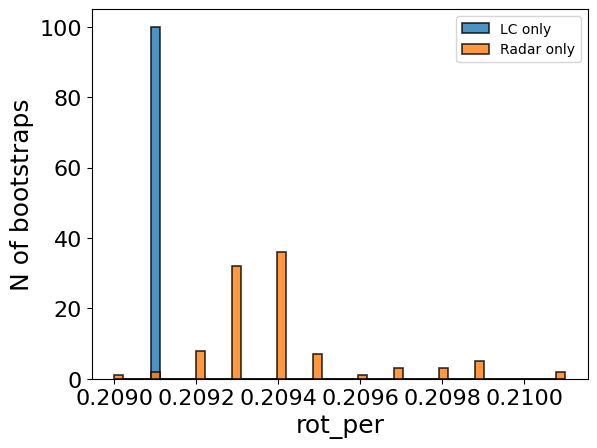

In [143]:
param_idx = 9
param_names = ['a1', 'b1', 'c1', 'a2', 'b2', 'c2', 'l', 'b', 'phi0', 'rot_per', 'radar_sat', 'pow_coeff']
nbins = 50
all_dens = np.concatenate([lc_results[:, param_idx], radar_results[:, param_idx]])
countds, bins = np.histogram(all_dens, bins=nbins)
plt.hist(lc_results[:, param_idx], bins=bins, alpha=0.8, linewidth=1.2, edgecolor='black', label='LC only')
plt.hist(radar_results[:, param_idx], bins=bins, alpha=0.8, linewidth=1.2, edgecolor='black', label='Radar only')
plt.xlabel(param_names[param_idx])
plt.ylabel('N of bootstraps')
plt.legend()

In [144]:
0.003 * 24 * 60

4.32

50 50 30


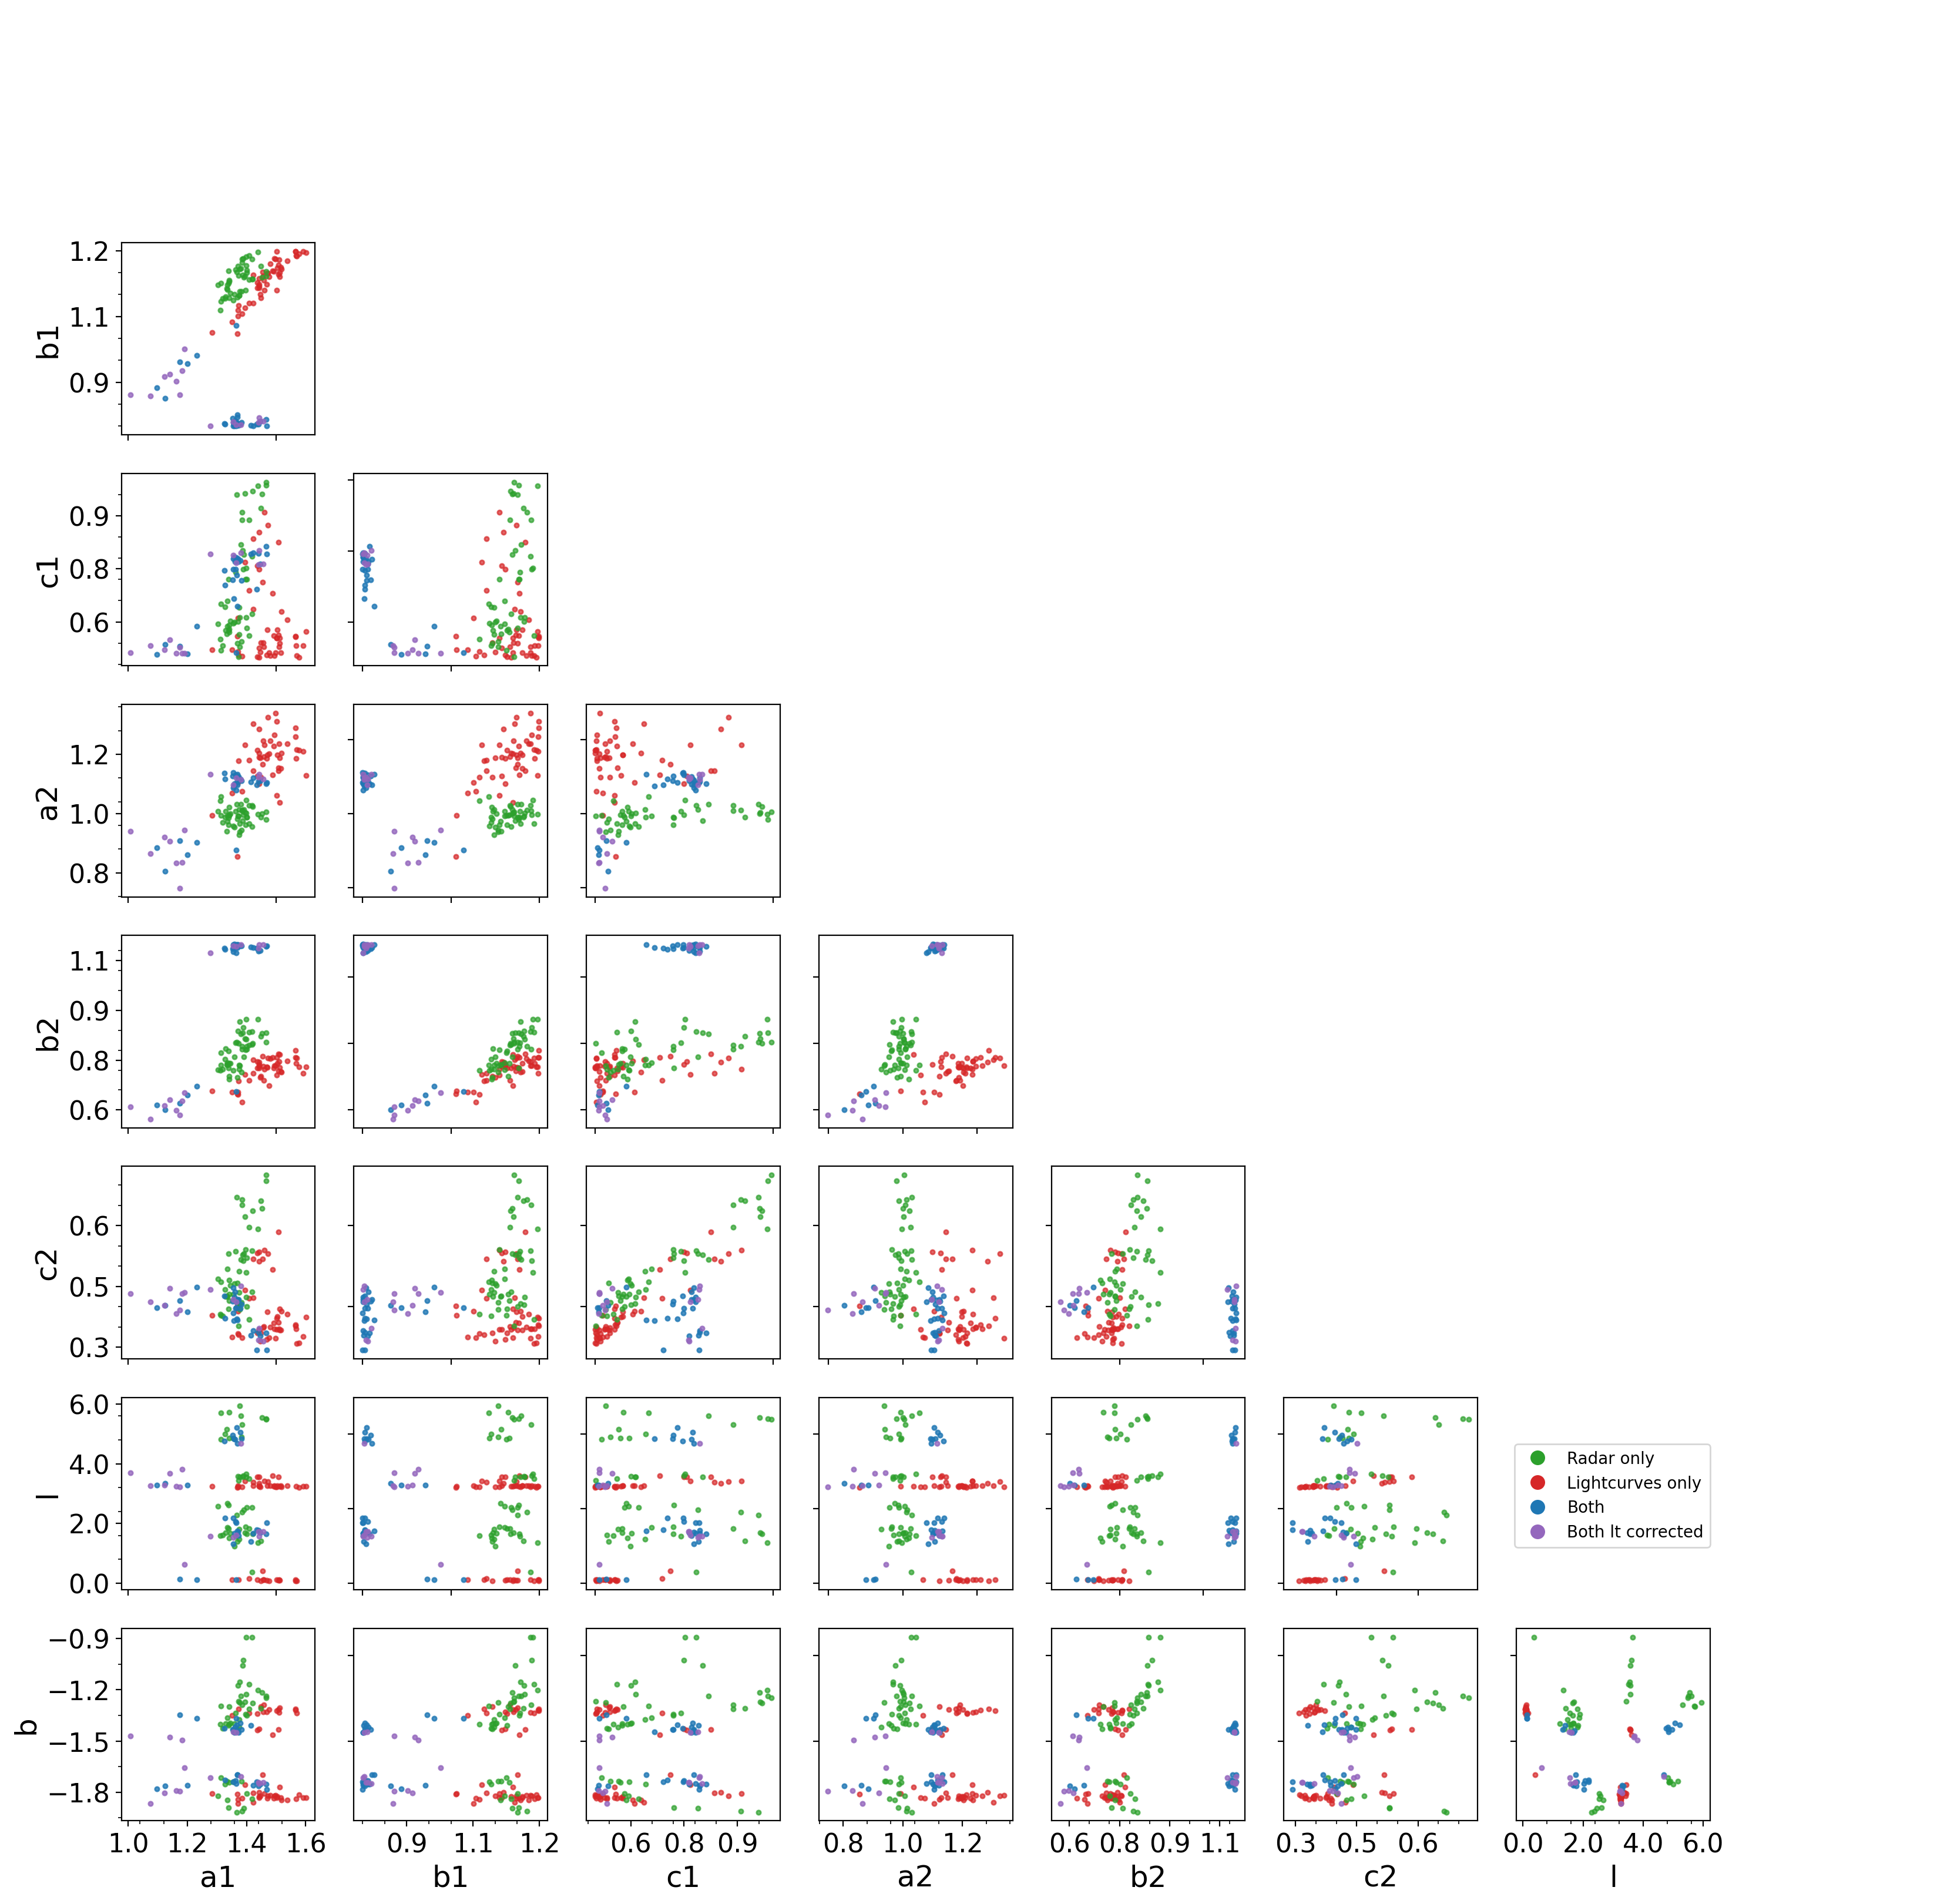

In [180]:
# read radar only and lightcurve only data
lc_results = np.array(func.read_bootstrap_from_file('data/lc_only_full_data.txt'))
radar_results = np.array(func.read_bootstrap_from_file('data/radar_only_full_data.txt'))
full_opt_results = np.array(func.read_bootstrap_from_file('data/fullopt_data_werner_3xerrs.txt'))
# select results (q=0.1) with lowest chi2
quant = 0.5
full_opt_best = full_opt_results[np.where(full_opt_results[:, 12] <= np.quantile(full_opt_results[:, 12], q=quant))]
lc_best = lc_results[np.where(lc_results[:, 12] <= np.quantile(lc_results[:, 12], q=quant))]
radar_best = radar_results[np.where(radar_results[:, 12] <= np.quantile(radar_results[:, 12], q=quant))]
print(len(lc_best), len(radar_best), len(full_opt_best))

labels=["a1", "b1", "c1", "a2", "b2", "c2", "l", "b", "phi0"]

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 15
point_size = 7
# Create a figure with subplots
fig, axes = plt.subplots(num_params, num_params, figsize=(20, 20), dpi=200)

for i in range(num_params):
    for j in range(num_params):
        if i <= j:
            # Skip the upper triangle and diagonal
            axes[i, j].axis('off')
        else:
            # plot bootstraps
            idx1, idx2 = j, i
            axes[i, j].scatter(lc_best[:, idx1], lc_best[:, idx2], label='lc_only', color='tab:red', s=point_size, alpha=0.7) # red is bootstrap
            axes[i, j].scatter(radar_best[:, idx1], radar_best[:, idx2], label='radar only', color='tab:green', s=point_size, alpha=0.7) # purple is fullopt
            axes[i, j].scatter(full_opt_best[:, idx1], full_opt_best[:, idx2], label='both', color='tab:blue', s=point_size, alpha=0.8)
            axes[i, j].scatter(lt_best[:, idx1], lt_best[:, idx2], label='both', color='tab:purple', s=point_size, alpha=0.8)

            # Remove labels for cleaner look
        if i < num_params - 1:
            axes[i, j].set_xticklabels([])
        if j > 0:
            axes[i, j].set_yticklabels([])
            # Add axis labels
        if i == num_params - 1:
            axes[i, j].set_xlabel(labels[j])
            axes[i, j].xaxis.set_major_locator(ticker.MaxNLocator(4))
            axes[i, j].xaxis.set_minor_locator(ticker.MaxNLocator(10))
            axes[i, j].xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))
        if j == 0:
            axes[i, j].set_ylabel(labels[i])
            axes[i, j].yaxis.set_major_locator(ticker.MaxNLocator(4))
            axes[i, j].yaxis.set_minor_locator(ticker.MaxNLocator(10))
            axes[i, j].yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1f}"))


handles = [
    plt.Line2D([], [], marker='o', color='w', label='Radar only', markerfacecolor='tab:green', markersize=10),
    plt.Line2D([], [], marker='o', color='w', label='Lightcurves only', markerfacecolor='tab:red', markersize=10),
    plt.Line2D([], [], marker='o', color='w', label='Both', markerfacecolor='tab:blue', markersize=10),
    plt.Line2D([], [], marker='o', color='w', label='Both lt corrected', markerfacecolor='tab:purple', markersize=10)
]

# Add legend to the figure
plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(-1.25, 2))
plt.show()